## Introduction

The pretraining stage in **COMPASS** establishes a biologically structured foundation for downstream clinical prediction tasks. Rather than directly learning from high-dimensional and noisy gene expression matrices, COMPASS leverages a **concept-bottleneck pretraining strategy** to build interpretable and disentangled transcriptomic representations.

Specifically, the model first embeds bulk RNA-seq features into **132 intermediate gene sets**, each corresponding to immune- and pathway-related biological programs, and then projects them into **44 high-level tumor immune microenvironment (TIME) concepts**. During pretraining on large-scale TCGA data, a contrastive learning objective is applied to encourage each concept embedding to be distinct and biologically coherent.

As a result, the learned **concept embeddings are well-separated in latent space**, with minimal overlap across different concepts, as shown by UMAP visualizations of both concept and gene set embeddings. This clear separation reflects the model’s ability to capture orthogonal immune axes—such as cytotoxic T cell activity, interferon response, or TGF-β signaling—without redundancy.

Such disentangled representations are expected to **benefit downstream tasks**, as each concept dimension contributes independently to response prediction or survival modeling. In other words, the pretraining stage not only transfers general immune knowledge but also enforces a structured representation space where **concepts are interpretable, independent, and biologically meaningful**, forming the foundation for fine-tuning and CRMap generation.



In [1]:
from compass import PreTrainer, FineTuner, loadcompass
from compass.tokenizer import CONCEPT, CONCEPT_palette
from compass.tokenizer import CANCER_CODE

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, MDS, LocallyLinearEmbedding
import os
sns.set(style = 'white', font_scale=1.5)
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.5)

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, MDS, LocallyLinearEmbedding

import colorcet as cc
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True, anote = True, margin = 12, swatch_width = 48):

    cell_width = 230
    cell_height = 30
    swatch_width = swatch_width
    margin = margin

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

        if anote:
            ax.text(swatch_start_x, y, colors[name], fontsize=10,
                    horizontalalignment='left', color = 'white',
                    verticalalignment='center')

    return fig

## 01. List of High-level Concepts

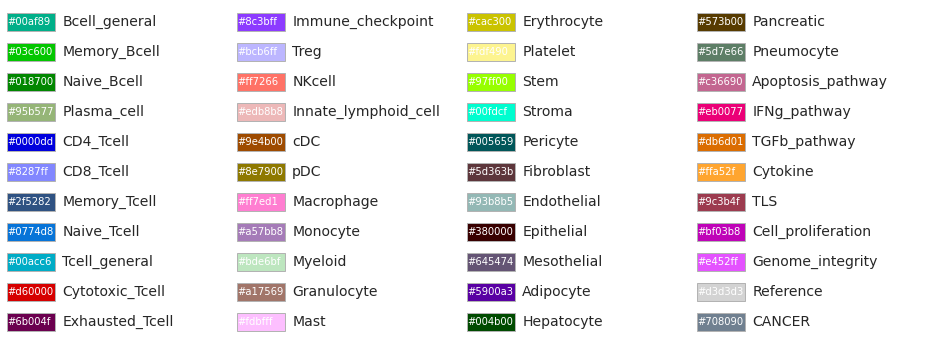

In [4]:
fig = plot_colortable(CONCEPT_palette, ncols=4, sort_colors = False)

## 02. List of Granular concepts (Gene sets)

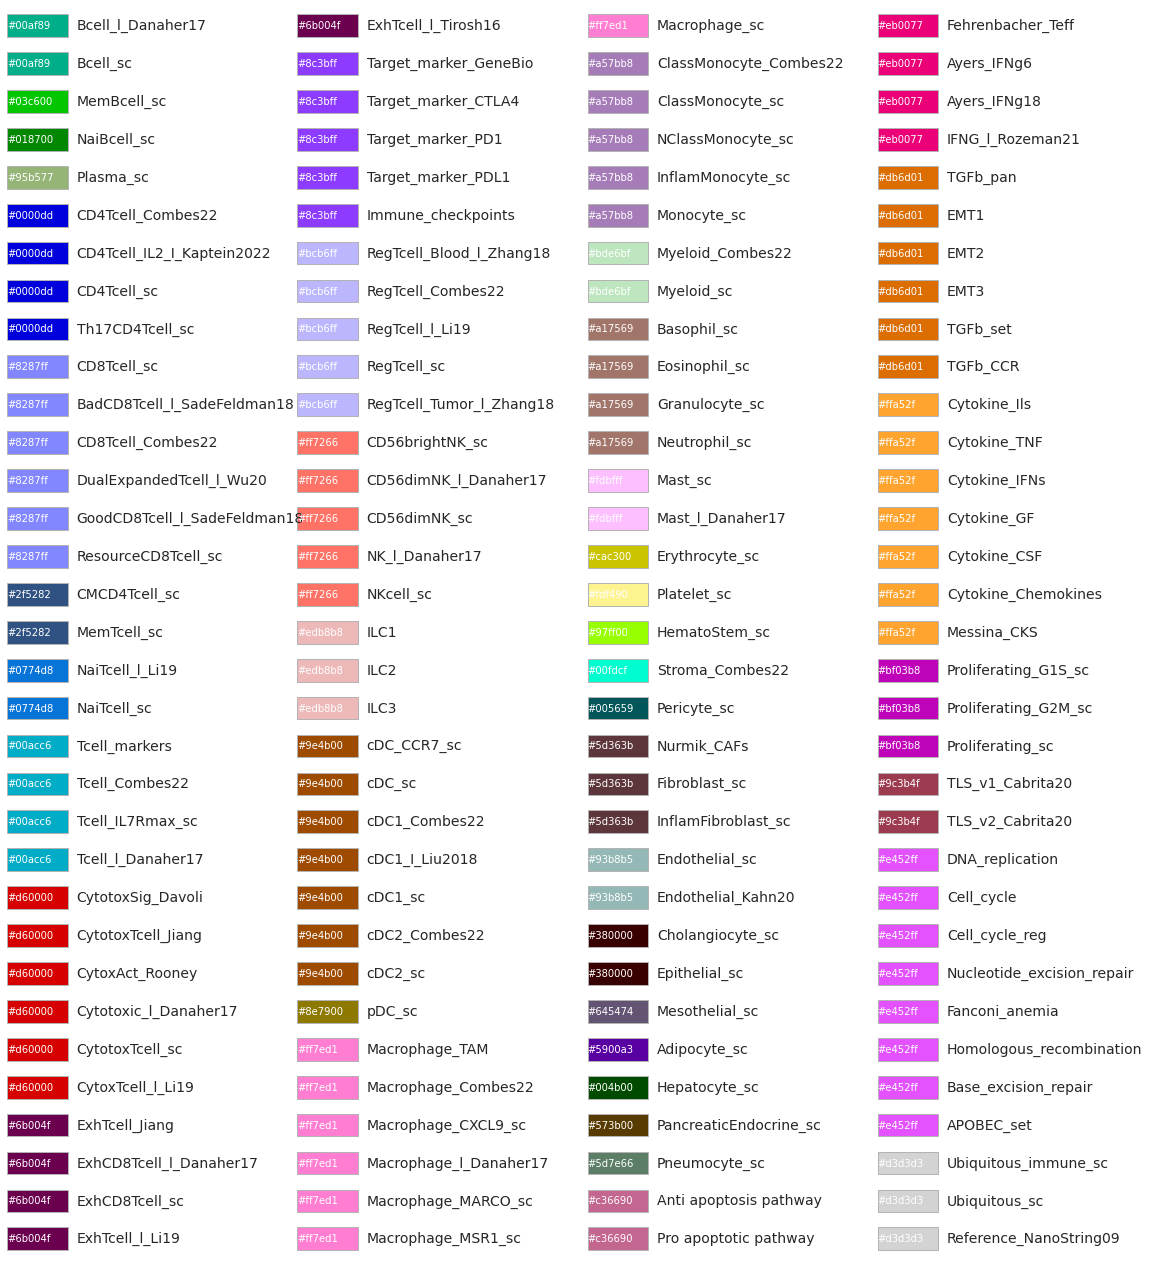

In [5]:
GENESET_palette = CONCEPT.BroadCelltypePathway.map(CONCEPT_palette).to_dict()
fig = plot_colortable(GENESET_palette, sort_colors = False, ncols=4,  margin = 150)
fig.tight_layout()

## 03. Extract TCGA Concept Feature (dim=32)

In [6]:
#pretrainer = loadcompass('./results/pretrainer.pt', map_location='cpu')
pretrainer = loadcompass('../../../checkpoint/latest/pretrainer.pt', map_location='cpu')
data_path = '/home/shenwanxiang/Research/aliyun_sync/COMPASS/paper/00_data/'
df_tpm = pd.read_pickle(os.path.join(data_path,  'TCGA.TPM.TABLE'))
df_label = pd.read_pickle(os.path.join(data_path, 'TCGA.PATIENT.PROCESSED.TABLE'))
dfcx = df_label.cancer_type.apply(lambda x:x.replace('TCGA-', '')).map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfcx.head()

,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
bcr_patient_barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5KT,0,0.0941,0.0000,254.8229,0.0175,43.5994,0.0000,77.5505,27.1029,165.9672,...,2.5086,17.4171,2.0131,5.8322,7.7030,0.0000,14.8143,79.6818,4.2798,11.5595
TCGA-OR-A5J9,0,0.0257,0.0000,327.3414,1.0576,19.1343,0.0000,58.4445,25.5385,0.0000,...,5.8691,35.6949,2.3158,5.1188,6.6314,0.0768,18.0190,87.6990,10.4959,13.2313
TCGA-OR-A5K0,0,0.1036,0.0000,208.2379,0.0810,2.6891,0.0000,47.7751,7.3294,25.5842,...,5.7894,27.4637,0.0000,0.0281,4.4084,0.1765,12.7103,163.0763,29.5753,5.3801
TCGA-OR-A5L6,0,0.1489,0.0000,90.1208,0.2635,4.6690,0.0558,52.3966,2.2953,0.4864,...,1.5546,15.4878,0.4825,0.8586,3.9806,0.0423,4.5830,15.7031,2.4108,3.8555
TCGA-OR-A5LT,0,0.0531,0.0368,34.5060,0.3855,15.6302,0.0398,35.3456,2.1698,3.8575,...,2.6830,21.8428,1.4790,3.6964,11.4081,0.0452,7.4563,37.9122,7.0122,4.1697


In [7]:
dfg, dfc = pretrainer.project(dfcx,  batch_size= 512)

100%|###################################################################################| 20/20 [05:05<00:00, 15.27s/it]


In [8]:
df_geneset_feat = pd.DataFrame(index=dfg.index)
df_geneset_feat['bcr_patient_barcode'] = dfg.index.map(lambda x:x.split('$$')[0])
df_geneset_feat['feature_name'] = dfg.index.map(lambda x:x.split('$$')[1])
df_geneset_feat = df_geneset_feat.join(dfg)
df_geneset_feat = df_geneset_feat.sort_values(['feature_name', 'bcr_patient_barcode'])

In [9]:
df_celltype_feat = pd.DataFrame(index=dfc.index)
df_celltype_feat['bcr_patient_barcode'] = dfc.index.map(lambda x:x.split('$$')[0])
df_celltype_feat['feature_name'] = dfc.index.map(lambda x:x.split('$$')[1])
df_celltype_feat = df_celltype_feat.join(dfc)
df_celltype_feat = df_celltype_feat.sort_values(['feature_name', 'bcr_patient_barcode'])

## 04. Concept UMAP embeddings

In [10]:
dfc = df_celltype_feat
data = dfc[dfc.columns[-32:]]
mp = UMAP(n_components = 2, n_neighbors= 100, n_epochs = 500,  
          min_dist=0.8, random_state = 42,   verbose=1 ) #
umap2d = mp.fit_transform(data)
df_umap2d  = pd.DataFrame(umap2d, index=dfc.index, columns = ['UMAP1', 'UMAP2'])
dfp = dfc[['bcr_patient_barcode', 'feature_name']].join(df_umap2d)


(-17.0587692, 38.4334852, -23.04156555, 38.34095455)

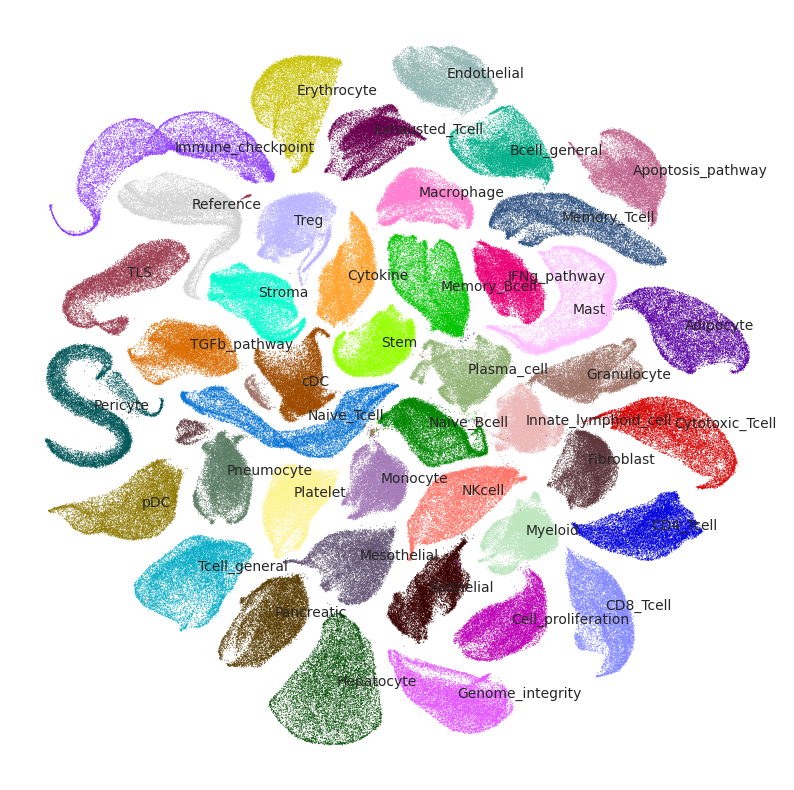

In [11]:
hue_order = CONCEPT_palette.keys()
hue_color = CONCEPT_palette.values()

fig, ax = plt.subplots(figsize=(10, 10))

x = 'UMAP1'
y = 'UMAP2'
hue = 'feature_name'

sns.scatterplot(data = dfp, x = x, y = y, hue = hue,  alpha = 0.8,
                linewidth=0.0, hue_order = hue_order, palette=hue_color, s = 0.5, 
                 ax=ax, legend=False)

mean = dfp.groupby(hue)[[x,y]].median()
for name in mean.index:
    s = mean.loc[name]
    ax.text(s[x], s[y], name,  fontdict={'fontsize':10})

ax.tick_params(bottom='on', left='off',  labelleft='on', labelbottom='on', pad=-.6,)
ax.set_xlabel('')
ax.set_ylabel('')

plt.axis('off')

## 05. Geneset UMAP embeddings

In [12]:
dfc = df_geneset_feat
data = dfc[dfc.columns[-32:]]
mp = UMAP(n_components = 2, n_neighbors=200,  min_dist=0.5, random_state = 42,   verbose=1 ) #
umap2d = mp.fit_transform(data)
df_umap2d  = pd.DataFrame(umap2d, index=data.index, columns = ['UMAP1', 'UMAP2'])
dfp = dfc[['bcr_patient_barcode', 'feature_name']].join(df_umap2d)

(-14.765346899999999, 32.6776069, -26.00282455, 26.11938955)

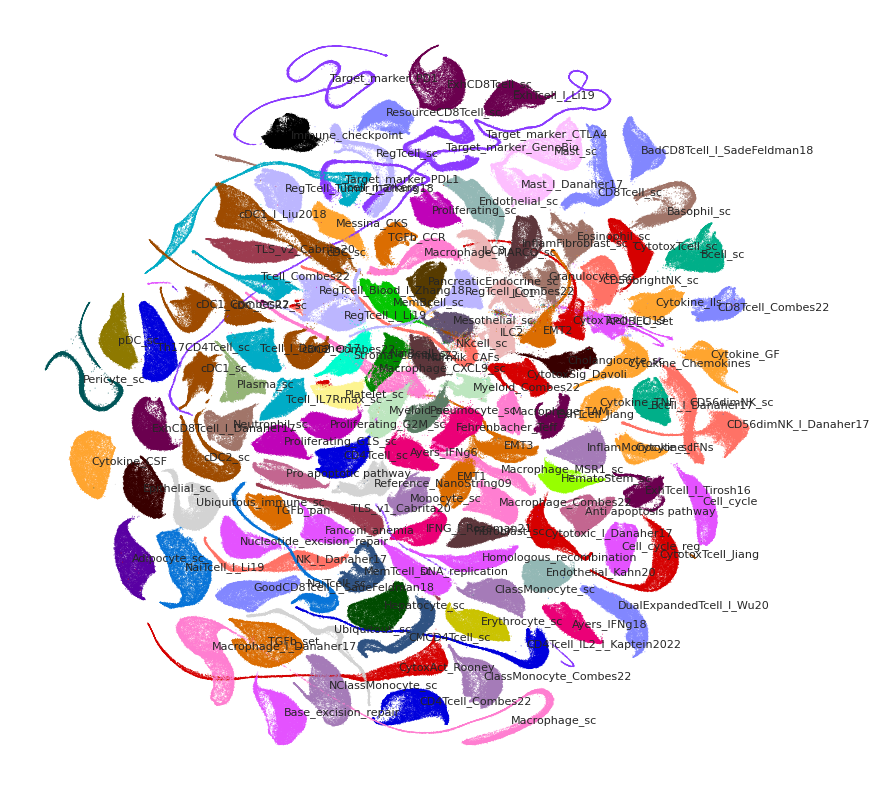

In [13]:
hue_order = GENESET_palette.keys()
hue_color = GENESET_palette.values()

fig, ax = plt.subplots(figsize=(10, 10))

x = 'UMAP1'
y = 'UMAP2'
hue = 'feature_name'

sns.scatterplot(data = dfp, x = x, y = y, hue = hue,  alpha = 0.8,
                linewidth=0.0, hue_order = hue_order, palette=hue_color, s = 0.5, 
                 ax=ax, legend=False)

mean = dfp.groupby(hue)[[x,y]].median()
for name in mean.index:
    s = mean.loc[name]
    ax.text(s[x], s[y], name,  fontdict={'fontsize':8})

ax.tick_params(bottom='on', left='off',  labelleft='on', labelbottom='on', pad=-.6,)
ax.set_xlabel('')
ax.set_ylabel('')
plt.axis('off')